# Credit Card Fraud Detection

### Libraries and Dataset Import

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import datetime as dt

In [2]:
df = pd.read_csv("archive/fraudTrain.csv", index_col="Unnamed: 0")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### Exploratory Data Analysis

In [3]:
print(f"Dataset size: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Dataset size: (1296675, 22)
Missing values: 0
Duplicate values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

In [5]:
df["trans_date_trans_time"]=pd.to_datetime(df["trans_date_trans_time"])
df["dob"]=pd.to_datetime(df["dob"])

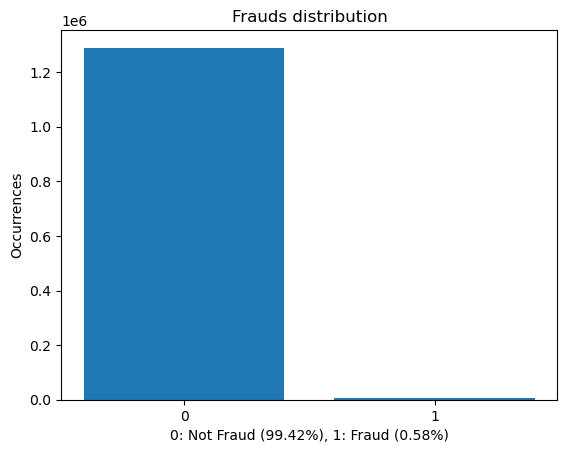

In [33]:
frauds=df["is_fraud"].value_counts()
fig,ax=plt.subplots()
ax.bar(frauds.index,frauds.values)
ax.set_xticks(frauds.index)
ax.set_title("Frauds distribution")
ax.set_xlabel(f"0: Not Fraud ({round(frauds[0]/frauds.sum()*100,2)}%), 1: Fraud ({round(frauds[1]/frauds.sum()*100,2)}%)")
ax.set_ylabel("Occurrences")
plt.show()

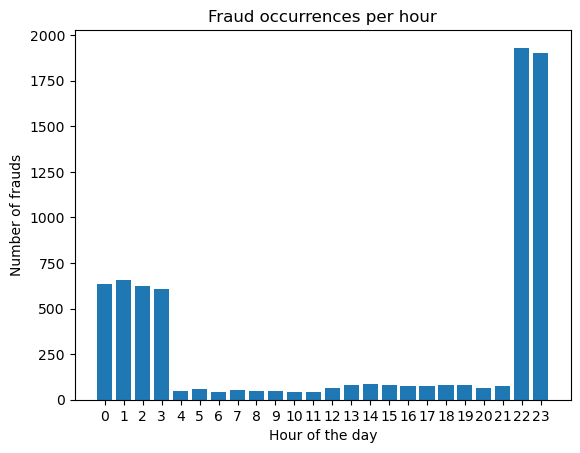

In [ ]:
trans_hour=df["trans_date_trans_time"].dt.hour
fraud_hour=df["trans_date_trans_time"][df["is_fraud"]==1].dt.hour
trans_hour_counts=trans_hour
fraud_hour_counts=fraud_hour.value_counts().sort_index()
fig,ax=plt.subplots()
ax.bar(np.arange(24),fraud_hour_counts)
ax.set_xticks(np.arange(24))
ax.set_xlabel("Hour of the day")
ax.set_ylabel("Number of frauds")
ax.set_title("Fraud occurrences per hour")
plt.show()


In [37]:
fraud_hour_counts

trans_date_trans_time
0      635
1      658
2      625
3      609
4       46
5       60
6       40
7       56
8       49
9       47
10      40
11      42
12      67
13      80
14      86
15      79
16      76
17      78
18      81
19      81
20      62
21      74
22    1931
23    1904
Name: count, dtype: int64